In [ ]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving crop_recommendation_final.csv to crop_recommendation_final.csv


In [ ]:
df = pd.read_csv('crop_recommendation_final.csv')

In [ ]:
df

,Unnamed: 0,N,P,K,temperature,humidity,ph,rainfall,label,fertilizer
0,0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice,DAP
1,1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice,DAP
2,2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice,Gypsum
3,3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice,DAP
4,4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice,Gypsum
...,...,...,...,...,...,...,...,...,...,...
16942,16942,154.0,88.0,36.0,31.360000,88.560000,7.580000,2790.710000,Wheat,MOP
16943,16943,113.0,77.0,48.0,26.400000,38.180000,7.170000,2792.240000,Wheat,MOP
16944,16944,73.0,45.0,34.0,17.890000,35.000000,7.920000,2040.090000,Wheat,MOP
16945,16945,32.0,32.0,119.0,18.590000,55.840000,6.820000,241.320000,Potato,Urea


In [ ]:
df.head()

,Unnamed: 0,N,P,K,temperature,humidity,ph,rainfall,label,fertilizer
0,0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice,DAP
1,1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice,DAP
2,2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice,Gypsum
3,3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice,DAP
4,4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice,Gypsum


In [ ]:
df['label'].value_counts()

,count
label,
Wheat,1467
Tomato,1451
Sugarcane,1428
Potato,1425
maize,1168
bengal gram,1159
rice,1149
blackgram,1145
rajma,1143


In [ ]:
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (16947, 10)
Columns: ['Unnamed: 0', 'N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'fertilizer']


In [ ]:
df = df.drop_duplicates()
df = df.dropna()
df.columns = df.columns.str.strip()

In [ ]:
print("\nUnique crops:", df['label'].unique())


Unique crops: ['rice' 'maize' 'bengal gram' 'rajma' 'kandulu' 'mothbeans' 'green gram'
 'blackgram' 'lentil' 'cotton' 'Sugarcane' 'Tomato' 'Wheat' 'Potato']


In [ ]:
crop_encoder = LabelEncoder()

df['crop_encoded'] = crop_encoder.fit_transform(df['label'])

print("\nCrop encoding:")
for i, c in enumerate(crop_encoder.classes_):
    print(f"  {i} = {c}")




Crop encoding:
  0 = Potato
  1 = Sugarcane
  2 = Tomato
  3 = Wheat
  4 = bengal gram
  5 = blackgram
  6 = cotton
  7 = green gram
  8 = kandulu
  9 = lentil
  10 = maize
  11 = mothbeans
  12 = rajma
  13 = rice


In [ ]:
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

X = df[feature_cols]
y = df['crop_encoded']

print(f"\nFeatures: {feature_cols}")
print(f"X shape: {X.shape}")


Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X shape: (16947, 7)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled=scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)

In [ ]:

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {acc * 100:.2f}%")


Model Accuracy: 72.09%


In [ ]:
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
rf = RandomForestClassifier(random_state=42)

crop_model = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

crop_model.fit(X_scaled_df, y)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=2)

In [ ]:
y_pred_crop = crop_model.predict(X_test)
crop_acc = accuracy_score(y_test, y_pred_crop)
print(f"\nModel Accuracy: {crop_acc * 100:.2f}%")


Model Accuracy: 99.65%


In [ ]:
print(crop_model.best_score_)

0.7154648694239822


In [ ]:
best_model = crop_model.best_estimator_

print("Best Params:", crop_model.best_params_)
print("CV Accuracy:", crop_model.best_score_ * 100)

Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
CV Accuracy: 71.54648694239822


In [ ]:
best_n = crop_model.best_params_['n_estimators']
print("Best n_estimators:", best_n)

Best n_estimators: 100


In [ ]:
with open('crop_model.pkl', 'wb') as f:
    pickle.dump(crop_model, f)

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
model_cr = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)
model_cr.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 150, 200]},
             scoring='accuracy', verbose=2)

In [ ]:
y_pred_sk = model_cr.predict(X_test)
acc_sk = accuracy_score(y_test, y_pred_sk)
print(f"\nModel Accuracy: {acc_sk * 100:.2f}%")


Model Accuracy: 71.36%


In [ ]:
with open('model_cr.pkl', 'wb') as f:
    pickle.dump(model_cr, f)

In [ ]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
rf = RandomForestClassifier(random_state=42)

cr_model = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

cr_model.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 150, 200]},
             scoring='accuracy', verbose=1)

In [ ]:
y_pred_ = cr_model.predict(X_test_scaled)
accu = accuracy_score(y_test, y_pred_)
print(f"\nModel Accuracy: {accu * 100:.2f}%")


Model Accuracy: 72.04%


In [ ]:
with open('cr_model.pkl', 'wb') as f:
    pickle.dump(cr_model, f)

In [ ]:
sample = pd.DataFrame(
    [[90, 42, 43, 20.8, 82.0, 6.5, 202.9]],
    columns=feature_cols
)
sample_scaled = pd.DataFrame(scaler.transform(sample), columns=feature_cols)

crop_id = crop_model.predict(sample_scaled)
crop_name = crop_encoder.inverse_transform(crop_id)[0]



In [ ]:
with open('model.pkl', 'wb') as f:
    pickle.dump(crop_model, f)
print("✅ Saved: crop_model.pkl")

with open('scaler_crop.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Saved: scaler_crop.pkl")

with open('crop_encoder.pkl', 'wb') as f:
    pickle.dump(crop_encoder, f)
print("✅ Saved: crop_encoder.pkl")

print("  - crop_model.pkl")
print("  - scaler_crop.pkl")
print("  - crop_encoder.pkl")

✅ Saved: crop_model.pkl
✅ Saved: scaler_crop.pkl
✅ Saved: crop_encoder.pkl
  - crop_model.pkl
  - scaler_crop.pkl
  - crop_encoder.pkl


In [ ]:
with open('model.pkl', 'wb') as f:
    pickle.dump(crop_model, f)

✅ Saved: crop_model.pkl


In [ ]:
with open('model_4.pkl', 'wb') as f:
    pickle.dump(cr_model, f)

✅ Saved: crop_model.pkl


In [ ]:
print(df.shape)
print(df['label'].nunique())
print(df['label'].value_counts())

(16947, 11)
14
label
Wheat          1467
Tomato         1451
Sugarcane      1428
Potato         1425
maize          1168
bengal gram    1159
rice           1149
blackgram      1145
rajma          1143
mothbeans      1117
green gram     1115
cotton         1108
kandulu        1054
lentil         1018
Name: count, dtype: int64


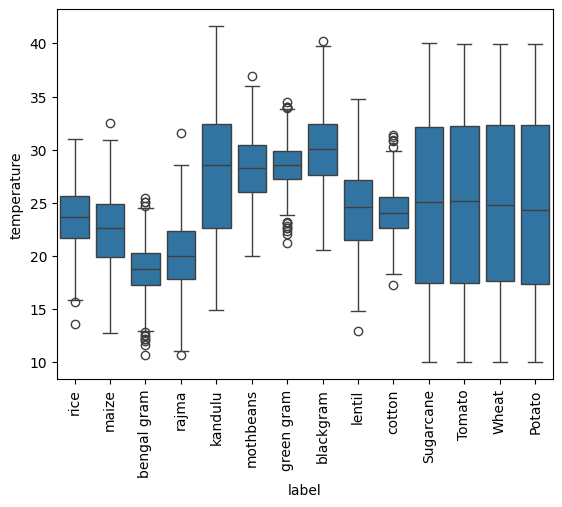

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='label', y='temperature')
plt.xticks(rotation=90)
plt.show()

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:58:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb) * 100)

XGBoost Accuracy: 71.74041297935104


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)


Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:03:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [4, 6, 8],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=2)

In [ ]:
best_xgb = grid.best_estimator_

xgb_y_pred = best_xgb.predict(X_test)

print("Best Params:", grid.best_params_)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_y_pred) * 100)

Best Params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 100}
XGBoost Accuracy: 71.65191740412979


In [ ]:
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

In [ ]:
with open('xgb_grid_model.pkl', 'wb') as f:
    pickle.dump(grid, f)

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

In [ ]:
voting_model= VotingClassifier(
    estimators=[
        ('dt', dt_model),
        ('rf', rf_model),
        ('xgb', xgb_model)
    ]
)

voting_model.fit(X_train, y_train)

y_pred = voting_model_soft.predict(X_test)

print("Soft Voting Accuracy:", accuracy_score(y_test, y_pred) * 100)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:45:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Soft Voting Accuracy: 71.47492625368731


In [ ]:
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.7141175164322152
Recall: 0.7147492625368732
F1 Score: 0.7062441588650084


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.24      0.53      0.33       290
           1       0.22      0.16      0.18       271
           2       0.27      0.16      0.20       293
           3       0.24      0.11      0.15       290
           4       1.00      1.00      1.00       238
           5       0.89      0.87      0.88       241
           6       0.97      0.98      0.98       203
           7       0.96      1.00      0.98       208
           8       0.93      0.96      0.95       206
           9       0.89      0.83      0.86       215
          10       0.97      0.97      0.97       247
          11       0.94      0.97      0.95       205
          12       0.99      0.98      0.99       232
          13       0.99      1.00      0.99       251

    accuracy                           0.71      3390
   macro avg       0.75      0.75      0.74      3390
weighted avg       0.71      0.71      0.71      3390

